# Model 1A, Experiment 08: Combined Rotation and 60-Minute Backlog

This controlled experiment tests whether a broader 60-minute view of JFK-wide operational backlog adds information beyond the flight-specific aircraft rotation state selected in Experiment 06. It combines the full-history rotation path and 24-hour long-turn mask with the same compact backlog definitions used in Experiment 07, recalculated over the preceding 60 minutes.

The Experiment 06 classifier is held fixed: L2 logistic regression with `C=1`, no class weighting, and every nonconstant prepared column. The notebook trains on 2019, selects operating thresholds only from held-out 2019 temporal predictions, and evaluates once on 2023. It does not load 2024 or write a combined feature dataset.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, f1_score, matthews_corrcoef, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load and pair the established feature paths

Rotation and backlog files are loaded independently. Row identity, population scope, targets, causal masks, and backlog arithmetic are validated before the compact backlog columns are attached in memory.

In [3]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in ("rotation_full_history", f"backlog_w{BACKLOG_WINDOW_MINUTES}")
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames = {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation_path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} backlog rows  <- {backlog_path.name}")

training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 backlog rows  <- JFK_2019_departures_backlog_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 backlog rows  <- JFK_2023_departures_backlog_w60.csv


In [4]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation, backlog = rotation_frames[partition], backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert len(rotation) == len(backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()
    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()
    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1
    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_pending": pending.mean(),
        "same_cutoff_backlog_violations": int(same_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary

,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_pending,same_cutoff_backlog_violations
partition,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0


## Apply the selected rotation mask and define the controlled comparison

Both variants use full raw movement history and the Experiment 06 rule that masks rotation matches with scheduled turns over 24 hours. The combined variant adds only pending count, completed count, and mean signed departure delay from the prior 60-minute scheduled cohort.

In [5]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
VARIANTS = {
    "rotation_only": {"backlog": []},
    "rotation_plus_backlog": {"backlog": COMPACT_BACKLOG_FEATURES},
}
FORBIDDEN_PREDICTORS = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
manifest_summary = pd.DataFrame({
    name: {"base_fields": len(BASE_CATEGORICAL_FEATURES) + len(BASE_NUMERIC_FEATURES),
           "rotation_fields": len(ROTATION_FEATURES),
           "backlog_fields": len(spec["backlog"])}
    for name, spec in VARIANTS.items()
}).T
for spec in VARIANTS.values():
    predictors = [*BASE_CATEGORICAL_FEATURES, *BASE_NUMERIC_FEATURES,
                  *ROTATION_CATEGORICAL, *ROTATION_NUMERIC, *spec["backlog"]]
    assert not FORBIDDEN_PREDICTORS.intersection(predictors)
manifest_summary

,base_fields,rotation_fields,backlog_fields
rotation_only,20,13,0
rotation_plus_backlog,20,13,3


In [6]:
def prepare_frame(frame: pd.DataFrame, backlog_features):
    categorical = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
    numeric = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *backlog_features]
    columns = list(dict.fromkeys(["FlightDate", "CRSDepTime", TARGET, *categorical, *numeric]))
    result = frame[columns].copy().sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    result[TARGET] = pd.to_numeric(result[TARGET], errors="raise").astype(int)
    for column in categorical:
        result[column] = result[column].astype(object)
    for column in numeric:
        result[column] = pd.to_numeric(result[column], errors="coerce")
    return result, categorical, numeric


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({"fold": fold, "train_rows": len(train_idx),
                     "validation_rows": len(heldout_idx),
                     "train_end": pd.Timestamp(train_days.max()).date(),
                     "validation_start": pd.Timestamp(heldout_days.min()).date(),
                     "validation_end": pd.Timestamp(heldout_days.max()).date(),
                     "validation_delay_rate": targets.iloc[heldout_idx].mean()})
    return splits, pd.DataFrame(rows).set_index("fold")

reference, _, _ = prepare_frame(model_frames["training"], [])
temporal_splits, fold_summary = make_expanding_day_splits(
    reference["FlightDate"], reference[TARGET], N_TIME_SPLITS
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,validation_delay_rate
fold,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1666


## Fit the fixed classifier and select thresholds from 2019

No feature-family or hyperparameter search is performed. Each variant receives the same training-only preprocessing and fixed Experiment 06 logistic classifier. The rotation-only control should reproduce Experiment 06 exactly.

In [7]:
def make_pipeline(categorical, numeric):
    return Pipeline([
        ("preprocessor", ColumnTransformer([
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical),
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
            ]), numeric),
        ], remainder="drop")),
        ("variance_filter", VarianceThreshold(0.0)),
        ("classifier", LogisticRegression(
            C=1.0, l1_ratio=0.0, solver="liblinear", class_weight=None,
            max_iter=5_000, random_state=RANDOM_STATE,
        )),
    ])


def classification_metrics(y, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold, "accuracy": accuracy_score(y, predictions),
        "balanced_accuracy": balanced_accuracy_score(y, predictions),
        "precision": precision_score(y, predictions, zero_division=0),
        "recall": recall_score(y, predictions, zero_division=0),
        "f1": f1_score(y, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y, predictions),
        "roc_auc": roc_auc_score(y, probabilities),
        "average_precision": average_precision_score(y, probabilities),
        "brier_score": brier_score_loss(y, probabilities),
    }


models, validation_probabilities, result_rows = {}, {}, []
experiment_start = perf_counter()
for variant_name, spec in VARIANTS.items():
    train, categorical, numeric = prepare_frame(model_frames["training"], spec["backlog"])
    validation, _, _ = prepare_frame(model_frames["validation"], spec["backlog"])
    features = [*categorical, *numeric]
    X_train, y_train = train[features], train[TARGET]
    X_validation, y_validation = validation[features], validation[TARGET]
    base_pipeline = make_pipeline(categorical, numeric)
    oof, fold_ap = np.full(len(train), np.nan), []
    for train_idx, heldout_idx in temporal_splits:
        fold_model = clone(base_pipeline).fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        fold_p = fold_model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
        oof[heldout_idx] = fold_p
        fold_ap.append(average_precision_score(y_train.iloc[heldout_idx], fold_p))
    oof_mask = np.isfinite(oof)
    threshold_candidates = []
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
        threshold_candidates.append(classification_metrics(
            y_train.to_numpy()[oof_mask], oof[oof_mask], threshold
        ))
    selected_threshold = float(pd.DataFrame(threshold_candidates).sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]["threshold"])
    final_model = clone(base_pipeline).fit(X_train, y_train)
    probabilities = final_model.predict_proba(X_validation)[:, 1]
    models[variant_name] = final_model
    validation_probabilities[variant_name] = probabilities
    encoded = final_model.named_steps["preprocessor"].get_feature_names_out()
    nonconstant = encoded[final_model.named_steps["variance_filter"].get_support()]
    for policy, threshold in [("default", 0.50), ("training_selected", selected_threshold)]:
        row = classification_metrics(y_validation, probabilities, threshold)
        row.update({"variant": variant_name, "threshold_policy": policy,
                    "training_cv_ap": np.mean(fold_ap),
                    "prepared_columns": len(nonconstant),
                    "backlog_fields": len(spec["backlog"])})
        result_rows.append(row)
    print(f"Completed {variant_name}: CV AP={np.mean(fold_ap):.4f}, 2023 AP={average_precision_score(y_validation, probabilities):.4f}")
experiment_seconds = perf_counter() - experiment_start
results = pd.DataFrame(result_rows).set_index(["variant", "threshold_policy"])
print(f"Total Experiment 08 fitting time: {experiment_seconds:,.1f} seconds")
results[["training_cv_ap", "average_precision", "roc_auc", "brier_score",
         "threshold", "accuracy", "balanced_accuracy", "precision",
         "recall", "f1", "mcc", "prepared_columns"]]

Completed rotation_only: CV AP=0.6375, 2023 AP=0.6960


Completed rotation_plus_backlog: CV AP=0.6577, 2023 AP=0.7053
Total Experiment 08 fitting time: 21.7 seconds


training_cv_ap  average_precision  \
variant               threshold_policy                                       
rotation_only         default                    0.6375             0.6960   
                      training_selected          0.6375             0.6960   
rotation_plus_backlog default                    0.6577             0.7053   
                      training_selected          0.6577             0.7053   

                                         roc_auc  brier_score  threshold  \
variant               threshold_policy                                     
rotation_only         default             0.8188       0.1222     0.5000   
                      training_selected   0.8188       0.1222     0.3100   
rotation_plus_backlog default             0.8267       0.1192     0.5000   
                      training_selected   0.8267       0.1192     0.2900   

                                         accuracy  balanced_accuracy  \
variant               threshold_policy                                 
rotation_only         default              0.8401             0.6825   
                      training_selected    0.8319             0.7236   
rotation_plus_backlog default              0.8430             0.6953   
                      training_selected    0.8259             0.7392   

                                         precision  recall     f1    mcc  \
variant               threshold_policy                                     
rotation_only         default               0.8648  0.3836 0.5315 0.5062   
                      training_selected     0.6932  0.5181 0.5930 0.4981   
rotation_plus_backlog default               0.8395  0.4151 0.5555 0.5164   
                      training_selected     0.6487  0.5746 0.6094 0.4994   

                                         prepared_columns  
variant               threshold_policy                     
rotation_only         default                         197  
                      training_selected               197  
rotation_plus_backlog default                         201  
                      training_selected               201

## Determine where backlog contributes

The overall 2023 result is primary. Subgroup diagnostics test the hypothesis that shared airport conditions are most helpful after the assigned aircraft has arrived or when rotation history is unavailable or excluded.

In [8]:
validation_frame = model_frames["validation"].sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
y_validation = pd.to_numeric(validation_frame[TARGET], errors="raise").astype(int)
status = validation_frame["ROTATION_STATUS"].astype("string")
populations = {
    "all rows": np.ones(len(validation_frame), dtype=bool),
    "excluding NOT_ARRIVED": status.ne("NOT_ARRIVED").to_numpy(),
    "ARRIVED": status.eq("ARRIVED").to_numpy(),
    "rotation unavailable/excluded": status.isin(["NO_PRIOR_EVENT", "PREVIOUS_EVENT_DEPARTURE",
                                                        "MISSING_TAIL", "LONG_TURN_EXCLUDED"]).to_numpy(),
}
diagnostic_rows = []
for variant_name, probabilities in validation_probabilities.items():
    for population, mask in populations.items():
        subgroup_y, subgroup_p = y_validation.to_numpy()[mask], probabilities[mask]
        diagnostic_rows.append({
            "variant": variant_name, "population": population, "rows": int(mask.sum()),
            "prevalence": subgroup_y.mean(),
            "average_precision": average_precision_score(subgroup_y, subgroup_p),
            "roc_auc": roc_auc_score(subgroup_y, subgroup_p),
            "brier_score": brier_score_loss(subgroup_y, subgroup_p),
        })
diagnostic_results = pd.DataFrame(diagnostic_rows).set_index(["population", "variant"])
diagnostic_results

,,rows,prevalence,average_precision,roc_auc,brier_score
population,variant,,,,,
all rows,rotation_only,109983,0.2364,0.6960,0.8188,0.1222
excluding NOT_ARRIVED,rotation_only,106418,0.2109,0.6034,0.7902,0.1262
ARRIVED,rotation_only,93108,0.1858,0.5806,0.7799,0.1145
rotation unavailable/excluded,rotation_only,13310,0.3866,0.6305,0.7247,0.2076
all rows,rotation_plus_backlog,109983,0.2364,0.7053,0.8267,0.1192
excluding NOT_ARRIVED,rotation_plus_backlog,106418,0.2109,0.6146,0.7993,0.1231
ARRIVED,rotation_plus_backlog,93108,0.1858,0.5904,0.7899,0.1123
rotation unavailable/excluded,rotation_plus_backlog,13310,0.3866,0.6565,0.7426,0.1986


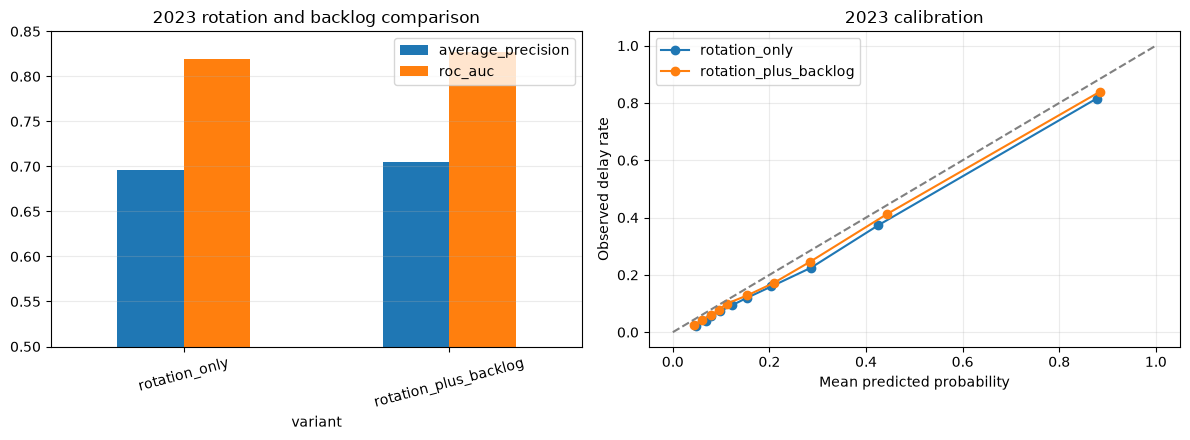

In [9]:
default = results.xs("default", level="threshold_policy")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
default[["average_precision", "roc_auc"]].plot.bar(ax=axes[0], rot=15)
axes[0].set_title("2023 rotation and backlog comparison")
axes[0].set_ylim(0.5, 0.85); axes[0].grid(axis="y", alpha=0.25)
for name, probabilities in validation_probabilities.items():
    predicted, observed = calibration_curve(y_validation, probabilities, n_bins=10, strategy="quantile")
    axes[1].plot(predicted, observed, marker="o", label=name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set(xlabel="Mean predicted probability", ylabel="Observed delay rate",
            title="2023 calibration")
axes[1].legend(); axes[1].grid(alpha=0.25)
fig.tight_layout(); plt.show()

## Inspect coefficients and publishable results

Standardized coefficients describe conditional associations, not causal effects. The experiment is retained even if backlog adds little, because it directly tests whether airport-wide state complements the aircraft-specific mechanism.

In [10]:
combined_model = models["rotation_plus_backlog"]
encoded = combined_model.named_steps["preprocessor"].get_feature_names_out()
selected_names = encoded[combined_model.named_steps["variance_filter"].get_support()]
coefficients = (pd.Series(combined_model.named_steps["classifier"].coef_[0], index=selected_names, name="coefficient")
    .rename_axis("feature").reset_index()
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False))
display(coefficients.head(25))
display(coefficients[coefficients["feature"].str.contains("BACKLOG_", regex=False)])

default = results.xs("default", level="threshold_policy")
selected = results.xs("training_selected", level="threshold_policy")
variant = "rotation_plus_backlog"
publishable_summary = pd.Series({
    "selected variant": variant,
    "classifier": "L2 logistic regression, C=1, no class weighting",
    "feature selection": "all nonconstant prepared columns",
    "training CV AP": default.loc[variant, "training_cv_ap"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default.loc[variant, "average_precision"],
    "validation ROC AUC": default.loc[variant, "roc_auc"],
    "validation Brier": default.loc[variant, "brier_score"],
    "selected threshold": selected.loc[variant, "threshold"],
    "selected-threshold accuracy": selected.loc[variant, "accuracy"],
    "selected-threshold balanced accuracy": selected.loc[variant, "balanced_accuracy"],
    "selected-threshold precision": selected.loc[variant, "precision"],
    "selected-threshold recall": selected.loc[variant, "recall"],
    "selected-threshold F1": selected.loc[variant, "f1"],
    "selected-threshold MCC": selected.loc[variant, "mcc"],
    "validation AP excluding NOT_ARRIVED": diagnostic_results.loc[("excluding NOT_ARRIVED", variant), "average_precision"],
    "validation AP delta vs rotation only": default.loc[variant, "average_precision"] - default.loc["rotation_only", "average_precision"],
    "validation Brier delta vs rotation only": default.loc[variant, "brier_score"] - default.loc["rotation_only", "brier_score"],
    "fit seconds": experiment_seconds,
}, name="Experiment 08 Appendix F values")
publishable_summary.to_frame()

,feature,coefficient,abs_coefficient
178,numeric__ROTATION_LOG_ACTUAL_TURN_MINUTES,-2.7693,2.7693
181,numeric__ROTATION_LOG_SCHEDULED_TURN_MINUTES,1.9031,1.9031
45,categorical__Dest_HNL,1.1379,1.1379
174,numeric__ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,1.0739,1.0739
26,categorical__Reporting_Airline_OH,-1.0322,1.0322
79,categorical__ROTATION_STATUS_ARRIVED,-0.9388,0.9388
152,categorical__ROTATION_INBOUND_ORIGIN_STT,0.8126,0.8126
28,categorical__Reporting_Airline_YX,-0.7693,0.7693
110,categorical__ROTATION_INBOUND_ORIGIN_IAD,-0.7667,0.7667
176,numeric__ROTATION_LOG_INBOUND_OVERDUE_MINUTES,-0.6198,0.6198


,feature,coefficient,abs_coefficient
182,numeric__BACKLOG_W60_PENDING_COUNT,0.2604,0.2604
184,numeric__BACKLOG_W60_MEAN_DEP_DELAY,0.1573,0.1573
183,numeric__BACKLOG_W60_COMPLETED_COUNT,-0.1206,0.1206
200,numeric__missingindicator_BACKLOG_W60_MEAN_DEP...,0.0320,0.0320


,Experiment 08 Appendix F values
selected variant,rotation_plus_backlog
classifier,"L2 logistic regression, C=1, no class weighting"
feature selection,all nonconstant prepared columns
training CV AP,0.6577
validation prevalence,0.2364
validation AP,0.7053
validation ROC AUC,0.8267
validation Brier,0.1192
selected threshold,0.2900
selected-threshold accuracy,0.8259


## Interpretation checklist

1. Does the rotation-only control reproduce Experiment 06?
2. Does compact backlog improve 2019 temporal AP and untouched 2023 AP, ROC AUC, or Brier score?
3. Is any gain retained after excluding `NOT_ARRIVED` flights and among already-arrived rotations?
4. Is backlog especially useful where rotation history is unavailable or excluded?
5. Do the three backlog coefficient signs remain operationally plausible after conditioning on rotation?
6. Preserve the final-tail caveat: the combined model remains a retrospective upper bound until timestamped assignment data are available.